# Feature Engineering


In [1]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(color_codes=True)

In [3]:
df = pd.read_csv('./clean_data_after_eda.csv')
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')

In [4]:
df.shape

(14606, 44)

In [5]:
df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,0.000011,2.896760e-06,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0


In [6]:
price_df = pd.read_csv('../eda/price_data.csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [7]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


In [8]:
#Average all 6 price dimensions per customer per month
mean_prices_by_month = price_df.groupby(['id', 'price_date']).agg({
    'price_off_peak_var': 'mean',
    'price_peak_var':     'mean',
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix':     'mean',
    'price_mid_peak_fix': 'mean'
}).reset_index()

#Calculate the difference between each pair of price periods per month
# Variable (energy) price differences
mean_prices_by_month['off_peak_peak_var_mean_diff']     = mean_prices_by_month['price_off_peak_var'] - mean_prices_by_month['price_peak_var']
mean_prices_by_month['peak_mid_peak_var_mean_diff']     = mean_prices_by_month['price_peak_var']     - mean_prices_by_month['price_mid_peak_var']
mean_prices_by_month['off_peak_mid_peak_var_mean_diff'] = mean_prices_by_month['price_off_peak_var'] - mean_prices_by_month['price_mid_peak_var']

# Fixed (power) price differences
mean_prices_by_month['off_peak_peak_fix_mean_diff']     = mean_prices_by_month['price_off_peak_fix'] - mean_prices_by_month['price_peak_fix']
mean_prices_by_month['peak_mid_peak_fix_mean_diff']     = mean_prices_by_month['price_peak_fix']     - mean_prices_by_month['price_mid_peak_fix']
mean_prices_by_month['off_peak_mid_peak_fix_mean_diff'] = mean_prices_by_month['price_off_peak_fix'] - mean_prices_by_month['price_mid_peak_fix']

print('Period difference columns created per month.')

Period difference columns created per month.


In [9]:
#Get the MAXIMUM monthly difference per customer across all months
# This captures the worst price spike a customer experienced during the year
max_diff = mean_prices_by_month.groupby('id').agg({
    'off_peak_peak_var_mean_diff':     'max',
    'peak_mid_peak_var_mean_diff':     'max',
    'off_peak_mid_peak_var_mean_diff': 'max',
    'off_peak_peak_fix_mean_diff':     'max',
    'peak_mid_peak_fix_mean_diff':     'max',
    'off_peak_mid_peak_fix_mean_diff': 'max'
}).reset_index().rename(columns={
    'off_peak_peak_var_mean_diff':     'off_peak_peak_var_max_monthly_diff',
    'peak_mid_peak_var_mean_diff':     'peak_mid_peak_var_max_monthly_diff',
    'off_peak_mid_peak_var_mean_diff': 'off_peak_mid_peak_var_max_monthly_diff',
    'off_peak_peak_fix_mean_diff':     'off_peak_peak_fix_max_monthly_diff',
    'peak_mid_peak_fix_mean_diff':     'peak_mid_peak_fix_max_monthly_diff',
    'off_peak_mid_peak_fix_mean_diff': 'off_peak_mid_peak_fix_max_monthly_diff'
})

print(f'Max monthly price diff features: {max_diff.shape[1]-1} new columns')
print(max_diff.head())

Max monthly price diff features: 6 new columns
                                 id  off_peak_peak_var_max_monthly_diff  \
0  0002203ffbb812588b632b9e628cc38d                            0.022225   
1  0004351ebdd665e6ee664792efc4fd13                            0.148405   
2  0010bcc39e42b3c2131ed2ce55246e3c                            0.205742   
3  0010ee3855fdea87602a5b7aba8e42de                            0.022581   
4  00114d74e963e47177db89bc70108537                            0.149902   

   peak_mid_peak_var_max_monthly_diff  off_peak_mid_peak_var_max_monthly_diff  \
0                            0.033743                                0.055866   
1                            0.000000                                0.148405   
2                            0.000000                                0.205742   
3                            0.031859                                0.054440   
4                            0.000000                                0.149902   

   off_peak_pea

In [10]:
def convert_months(reference_date, df, column):
    """
    Calculate the number of whole months between a reference date
    and a date column in a dataframe.
    
    More precise than simply dividing days by 30,
    because it accounts for actual calendar months.
    """
    dates = pd.to_datetime(df[column])

    year_diff  = reference_date.year  - dates.dt.year
    month_diff = reference_date.month - dates.dt.month

    # Total months = years * 12 + remaining months
    months = year_diff * 12 + month_diff

    # Subtract 1 if reference day hasn't been reached yet in that month
    months -= (reference_date.day < dates.dt.day).astype(int)

    return months

In [11]:
# Reference date: snapshot of our dataset (treat as 'today')
from datetime import datetime
reference_date = datetime(2016, 1, 1)

# months_activ: how long has customer been with PowerCo?
# reference - activation = months active (positive = past)
df['months_activ'] = convert_months(reference_date, df, 'date_activ')

# months_to_end: how many months until contract ends?
# Negative of (reference - end date) = positive = future months remaining
df['months_to_end'] = -convert_months(reference_date, df, 'date_end')

# months_modif_prod: months since customer last changed their product/plan
df['months_modif_prod'] = convert_months(reference_date, df, 'date_modif_prod')

# months_renewal: months since last contract renewal
df['months_renewal'] = convert_months(reference_date, df, 'date_renewal')

print('Date features created:')
print(df[['months_activ', 'months_to_end',
          'months_modif_prod', 'months_renewal']].describe().round(1))

Date features created:
       months_activ  months_to_end  months_modif_prod  months_renewal
count       14606.0        14606.0            14606.0         14606.0
mean           58.6            7.4               35.5             4.8
std            19.4            3.5               30.3             3.9
min            16.0            1.0               -1.0            -1.0
25%            44.0            4.0                6.0             2.0
50%            57.0            7.0               30.0             5.0
75%            71.0           10.0               64.0             8.0
max           151.0           18.0              151.0            30.0


In [12]:
# Now that we've extracted all useful information, drop the raw date columns
# Models cannot use datetime objects directly
df = df.drop(columns=['date_activ', 'date_end', 'date_modif_prod', 'date_renewal'])
print(f'Columns after dropping raw dates: {df.shape[1]}')

Columns after dropping raw dates: 44


In [13]:
# Convert has_gas: 't' → 1, 'f' → 0
df['has_gas'] = df['has_gas'].replace(['t', 'f'], [1, 0])

# Validate: check churn rate by gas status
# If rates differ, the feature has predictive power
print('Churn rate by has_gas:')
print(df.groupby('has_gas').agg({'churn': 'mean'}).round(4))
print('\nCustomers with gas are slightly less likely to churn')
print('(higher switching costs = more loyalty)')

Churn rate by has_gas:
          churn
has_gas        
0        0.1005
1        0.0819

Customers with gas are slightly less likely to churn
(higher switching costs = more loyalty)


In [14]:
cols_to_encode = ['channel_sales', 'origin_up']
min_count = 100  # Drop categories with fewer than 100 customers

# Store category counts BEFORE encoding
value_counts = {col: df[col].value_counts() for col in cols_to_encode}

print('Category counts before encoding:')
for col in cols_to_encode:
    print(f'\n{col}:')
    print(value_counts[col])
    rare = value_counts[col][value_counts[col] < min_count]
    print(f'  → Will DROP {len(rare)} rare categories (< {min_count} customers)')

Category counts before encoding:

channel_sales:
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64
  → Will DROP 3 rare categories (< 100 customers)

origin_up:
origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64
  → Will DROP 3 rare categories (< 100 customers)


In [15]:
# Apply one-hot encoding
df = pd.get_dummies(df, columns=cols_to_encode, prefix=cols_to_encode, dtype=int)

# Drop rare category columns (< 100 customers)
for col in cols_to_encode:
    keep = set(value_counts[col][value_counts[col] >= min_count].index.astype(str))
    dummy_cols = [c for c in df.columns if c.startswith(f'{col}_')]
    drop_cols  = [c for c in dummy_cols if c.split(f'{col}_', 1)[1] not in keep]
    df.drop(columns=drop_cols, inplace=True)
    print(f'Dropped {len(drop_cols)} rare columns from {col}')

print(f'\nColumns after encoding: {df.shape[1]}')

Dropped 3 rare columns from channel_sales
Dropped 3 rare columns from origin_up

Columns after encoding: 50


In [16]:
# Columns identified as skewed during EDA
skewed_cols = [
    'cons_12m',
    'cons_gas_12m',
    'cons_last_month',
    'forecast_cons_12m',
    'forecast_cons_year',
    'forecast_discount_energy',
    'forecast_meter_rent_12m',
    'forecast_price_energy_off_peak',
    'forecast_price_energy_peak',
    'forecast_price_pow_off_peak'
]

print('Standard deviations BEFORE log transform:')
print(df[skewed_cols].std().round(2))

# Apply log10(x + 1) in-place — overwrites the original columns
df[skewed_cols] = np.log10(df[skewed_cols] + 1)

print('\nStandard deviations AFTER log transform:')
print(df[skewed_cols].std().round(4))
print('\nAll standard deviations reduced — distributions are now more normal')

Standard deviations BEFORE log transform:
cons_12m                          573465.26
cons_gas_12m                      162973.06
cons_last_month                    64364.20
forecast_cons_12m                   2387.57
forecast_cons_year                  3247.79
forecast_discount_energy               5.11
forecast_meter_rent_12m               66.17
forecast_price_energy_off_peak         0.02
forecast_price_energy_peak             0.05
forecast_price_pow_off_peak            4.49
dtype: float64

Standard deviations AFTER log transform:
cons_12m                          0.8845
cons_gas_12m                      1.7171
cons_last_month                   1.7693
forecast_cons_12m                 0.6836
forecast_cons_year                1.5850
forecast_discount_energy          0.2674
forecast_meter_rent_12m           0.5715
forecast_price_energy_off_peak    0.0094
forecast_price_energy_peak        0.0203
forecast_price_pow_off_peak       0.1342
dtype: float64

All standard deviations reduced — d

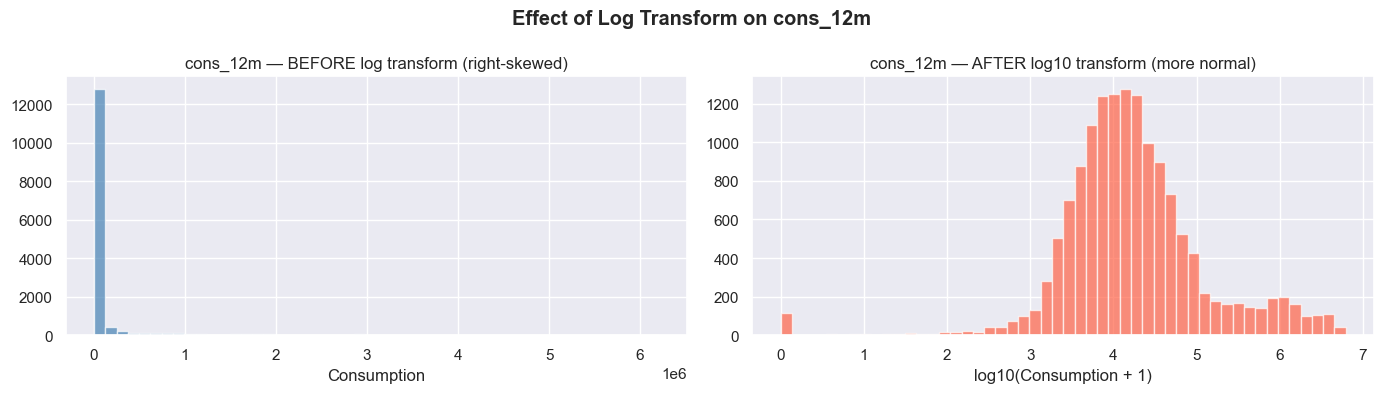

In [17]:
# Visual check: before vs after for cons_12m
# We reload raw data just for visualisation — not modifying df
raw_check = pd.read_csv('./clean_data_after_eda.csv')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

raw_check['cons_12m'].hist(bins=50, ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('cons_12m — BEFORE log transform (right-skewed)')
axes[0].set_xlabel('Consumption')

df['cons_12m'].hist(bins=50, ax=axes[1], color='tomato', alpha=0.7)
axes[1].set_title('cons_12m — AFTER log10 transform (more normal)')
axes[1].set_xlabel('log10(Consumption + 1)')

plt.suptitle('Effect of Log Transform on cons_12m', fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Merge 1: Estelle's Dec vs Jan diff features
df = pd.merge(df, diff, on='id', how='left')
print(f'After merging Estelle features: {df.shape[1]} columns')

# Merge 2: Max monthly price period differences
df = pd.merge(df, max_diff, on='id', how='left')
print(f'After merging max diff features: {df.shape[1]} columns')

After merging Estelle features: 52 columns
After merging max diff features: 58 columns


In [19]:
# Check all columns are numeric (no remaining text)
non_numeric = df.select_dtypes(include=['object']).columns.tolist()
print('Non-numeric columns (should be empty):')
print(non_numeric if non_numeric else ' None — all columns are numeric')

Non-numeric columns (should be empty):
['id', 'has_gas']


C:\Users\Manju\AppData\Local\Temp\ipykernel_7960\677439085.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  non_numeric = df.select_dtypes(include=['object']).columns.tolist()


In [20]:
# Check for null values introduced by merges
nulls = df.isnull().sum()
nulls_found = nulls[nulls > 0]
if len(nulls_found) > 0:
    print('⚠️  Null values found — investigate:')
    print(nulls_found)
else:
    print('✅ No null values found')

✅ No null values found


In [21]:
# Confirm churn column is intact
print('Churn distribution check:')
print(df['churn'].value_counts())
print(f'Churn rate: {df["churn"].mean()*100:.1f}% (should still be ~9.7%)')

Churn distribution check:
churn
0    13187
1     1419
Name: count, dtype: int64
Churn rate: 9.7% (should still be ~9.7%)


In [22]:
# Final shape
print(f'Final dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nAll feature columns:')
for i, col in enumerate(df.columns):
    print(f'  {i+1:2}. {col}')

Final dataset: 14,606 rows x 58 columns

All feature columns:
   1. id
   2. cons_12m
   3. cons_gas_12m
   4. cons_last_month
   5. forecast_cons_12m
   6. forecast_cons_year
   7. forecast_discount_energy
   8. forecast_meter_rent_12m
   9. forecast_price_energy_off_peak
  10. forecast_price_energy_peak
  11. forecast_price_pow_off_peak
  12. has_gas
  13. imp_cons
  14. margin_gross_pow_ele
  15. margin_net_pow_ele
  16. nb_prod_act
  17. net_margin
  18. num_years_antig
  19. pow_max
  20. var_year_price_off_peak_var
  21. var_year_price_peak_var
  22. var_year_price_mid_peak_var
  23. var_year_price_off_peak_fix
  24. var_year_price_peak_fix
  25. var_year_price_mid_peak_fix
  26. var_year_price_off_peak
  27. var_year_price_peak
  28. var_year_price_mid_peak
  29. var_6m_price_off_peak_var
  30. var_6m_price_peak_var
  31. var_6m_price_mid_peak_var
  32. var_6m_price_off_peak_fix
  33. var_6m_price_peak_fix
  34. var_6m_price_mid_peak_fix
  35. var_6m_price_off_peak
  36. var_6m_